# Spotify EDA

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'AppleGothic'  # Mac 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지

print("pandas", pd.__version__)
print("numpy", np.__version__)
print("seaborn", sns.__version__)
print("준비 완료!")

pandas 2.2.2
numpy 1.26.4
seaborn 0.13.2
준비 완료!


In [47]:
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')
df.head()
# dataset size 측정
# 953개 행, 24개 컬럼
print(df.shape)

(953, 24)


## 1단계 — 데이터 전처리
목표: 결측치 확인, 데이터 타입 점검 및 정제

In [48]:
# 결측치 확인
df.isnull().sum()
# in_shazam_charts 결측치 50개, key 결측치 95개

track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64

In [49]:
# null이 아닌 데이터 수 계산
df.count()

track_name              953
artist(s)_name          953
artist_count            953
released_year           953
released_month          953
released_day            953
in_spotify_playlists    953
in_spotify_charts       953
streams                 953
in_apple_playlists      953
in_apple_charts         953
in_deezer_playlists     953
in_deezer_charts        953
in_shazam_charts        903
bpm                     953
key                     858
mode                    953
danceability_%          953
valence_%               953
energy_%                953
acousticness_%          953
instrumentalness_%      953
liveness_%              953
speechiness_%           953
dtype: int64

In [50]:
# dataset 타입 확인
df.dtypes
# 문제 - streams 숫자처럼 보이는데 object type > 집계할 때 문제가 생긴다.

track_name              object
artist(s)_name          object
artist_count             int64
released_year            int64
released_month           int64
released_day             int64
in_spotify_playlists     int64
in_spotify_charts        int64
streams                 object
in_apple_playlists       int64
in_apple_charts          int64
in_deezer_playlists     object
in_deezer_charts         int64
in_shazam_charts        object
bpm                      int64
key                     object
mode                    object
danceability_%           int64
valence_%                int64
energy_%                 int64
acousticness_%           int64
instrumentalness_%       int64
liveness_%               int64
speechiness_%            int64
dtype: object

In [51]:
# streams 컬럼이 object인 이유가 숫자가 아닌 값(쉼표, 문자 등)이 섞여 있을 수 있기 때문에
# errors 옵션을 추가해서 강제로 처리
# errors='coerce' 숫자로 변환 불가능한 값은 NaN으로 변경
df["streams"] = pd.to_numeric(df["streams"], errors='coerce')

In [52]:
# 숫자로 변환되지 않아 결측치가 된 데이터가 있는지 확인
# 953개 중 1개 결측 - 데이터의 0.1% 정도기 때문에 행을 제거하는 것이 낫다
# 평균으로 대체 X - BTS와 신인 아티스트가 같은 데이터 안에 있기 때문에 평균이 실제 스트리밍 수를 대표할 수 없다
df["streams"].isnull().sum()

1

In [53]:
# streams 컬럼 기준으로만 제거
df = df.dropna(subset=['streams'])
print(df.shape)

(952, 24)


### 1단계 — 결과

- `streams` 컬럼이 object 타입 → `pd.to_numeric()`으로 int64 변환
- 변환 과정에서 NaN 1개 발생 (전체의 0.1%) → `dropna()`로 제거
- 최종 데이터: 952행, 24컬럼
- 결측치: `key` 95개, `in_shazam_charts` 50개 → 분석 시 그때그때 처리

## 2단계 - 아티스트 & 트랙 집계 분석

In [54]:
# 스트리밍 Top 10 아티스트
# 지수 표기법에서 숫자 포맷 변경
pd.options.display.float_format = '{:,.0f}'.format
df.groupby("artist(s)_name")["streams"].sum().sort_values(ascending=False).head(10)

artist(s)_name
The Weeknd        14,185,552,870
Taylor Swift      14,053,658,300
Ed Sheeran        13,908,947,204
Harry Styles      11,608,645,649
Bad Bunny          9,997,799,607
Olivia Rodrigo     7,442,148,916
Eminem             6,183,805,596
Bruno Mars         5,846,920,599
Arctic Monkeys     5,569,806,731
Imagine Dragons    5,272,484,650
Name: streams, dtype: float64

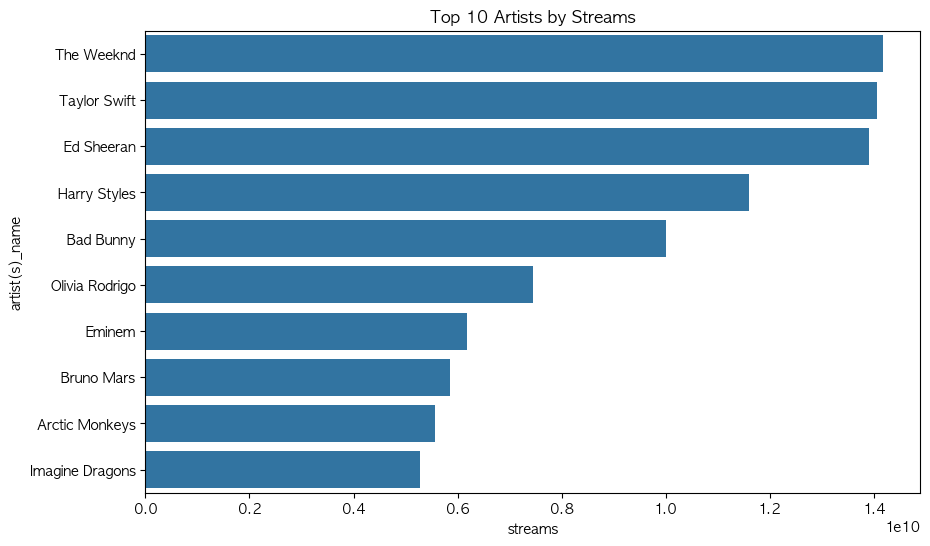

In [55]:
# df.groupby("artist(s)_name")["streams"].sum().sort_values(ascending=False).head(10) Series(1차원)로 출력된다.
# barplot으로 시각화 하기 위해서는 DataFrame(2차원)이 필요함
# reset_index()로 index로 되어 있던 artist(s)_name을 컬럼으로 꺼내줘야한다.
top10 = df.groupby("artist(s)_name")["streams"].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=top10,x="streams",y="artist(s)_name")
plt.title("Top 10 Artists by Streams")
plt.show()

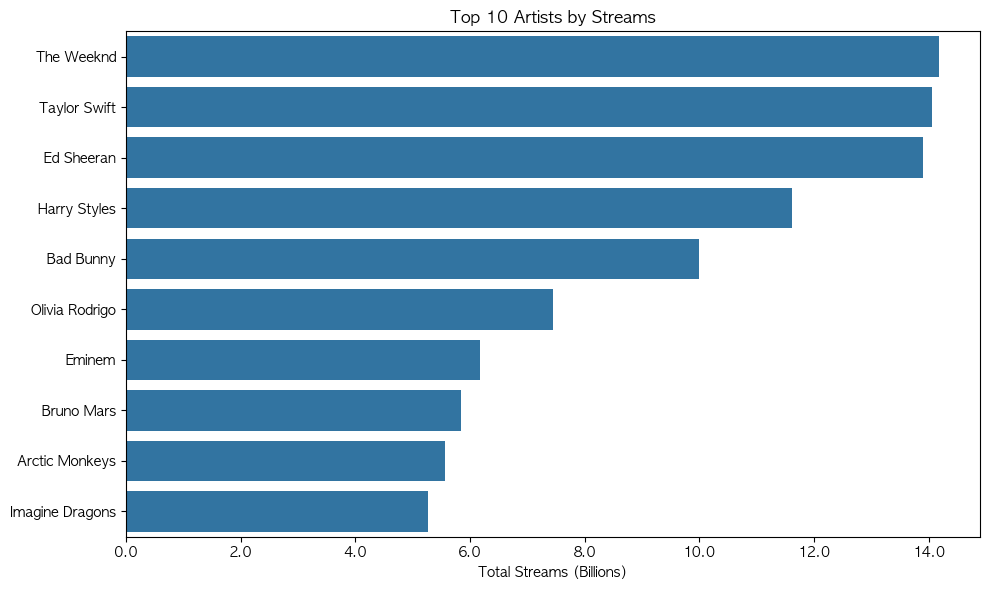

In [56]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x="streams", y="artist(s)_name")
plt.title("Top 10 Artists by Streams")
plt.xlabel("Total Streams (Billions)")
plt.ylabel("")
# plt.ticklabel_format(style="plain", axis="x")  # 지수 표기 제거
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e9:.1f}')) #
plt.tight_layout() # 제목, 축 레이블, 눈금이 서로 겹치지 않게 자동으로 여백을 조정
plt.show()

## 3단계 오디오 피처 상관관계 분석

In [57]:
# 상관관계 분석하려면 수치형 컬럼만 뽑아야 한다.
df.select_dtypes("number")

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,2,2023,7,14,553,147,"141,381,703",43,263,10,125,80,89,83,31,0,8,4
1,1,2023,3,23,1474,48,"133,716,286",48,126,14,92,71,61,74,7,0,10,4
2,1,2023,6,30,1397,113,"140,003,974",94,207,14,138,51,32,53,17,0,31,6
3,1,2019,8,23,7858,100,"800,840,817",116,207,12,170,55,58,72,11,0,11,15
4,1,2023,5,18,3133,50,"303,236,322",84,133,15,144,65,23,80,14,63,11,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,1,2022,11,3,953,0,"91,473,363",61,13,1,144,60,24,39,57,0,8,3
949,1,2022,10,21,1180,0,"121,871,870",4,0,0,166,42,7,24,83,1,12,6
950,2,2022,11,3,573,0,"73,513,683",2,0,0,92,80,81,67,4,0,8,6
951,3,2022,10,20,1320,0,"133,895,612",29,26,0,97,82,67,77,8,0,12,5


In [58]:
# 방법 1 — 직접 리스트로
# audio_features = df[["danceability_%", "valence_%", ...]]

# 방법 2 — 컬럼명 패턴으로
audio_features = df[[col for col in df.columns if col.endswith("_%")]]

In [59]:
# 오디오피쳐 컬럼들 간의 상관관계 구하기
corr_matrix = audio_features.corr()
print(corr_matrix.round(4))

                    danceability_%  valence_%  energy_%  acousticness_%  \
danceability_%                   1          0         0              -0   
valence_%                        0          1         0              -0   
energy_%                         0          0         1              -1   
acousticness_%                  -0         -0        -1               1   
instrumentalness_%              -0         -0        -0               0   
liveness_%                      -0          0         0              -0   
speechiness_%                    0          0        -0              -0   

                    instrumentalness_%  liveness_%  speechiness_%  
danceability_%                      -0          -0              0  
valence_%                           -0           0              0  
energy_%                            -0           0             -0  
acousticness_%                       0          -0             -0  
instrumentalness_%                   1          -0         

In [60]:
print(corr_matrix['energy_%']['acousticness_%'])

-0.5773182106878039


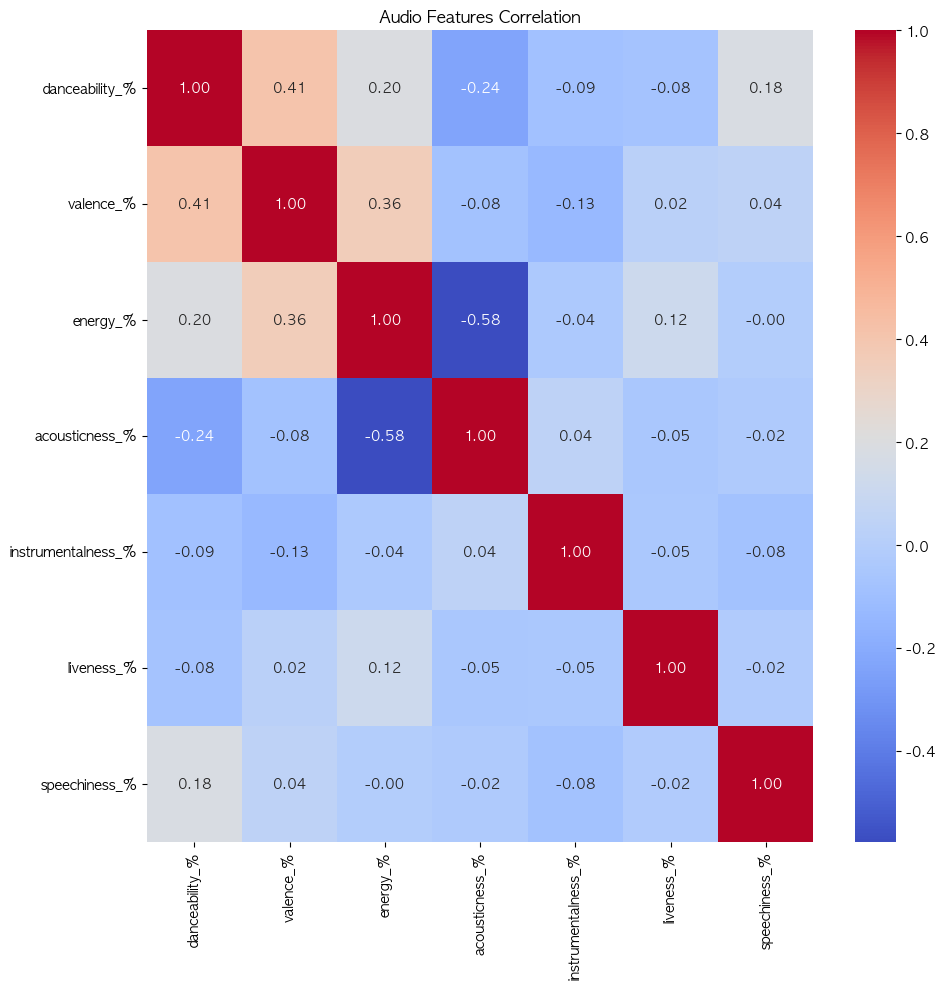

In [61]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Audio Features Correlation")
plt.tight_layout()
plt.show()

### 3단계 결과
heatmap을 활용하여 오디오피쳐들 간의 상관관계를 분석한 결과는 아래와 같다.
- energy ↔ acousticness = -0.58 → 강한 음의 상관관계. 에너지 넘치는 곡일수록 어쿠스틱하지 않음
- danceability ↔ valence = 0.41 → 중간 양의 상관관계. 신나는 곡이 긍정적인 감정도 높음
- energy ↔ valence = 0.36 → 중간 양의 상관관계. 에너지 넘치는 곡이 긍정적인 감정도 높음
- danceability ↔ speechiness = 0.18 → 거의 관계 없음

** 범위해석 **\
0.7         이상강한 상관\
0.4 ~ 0.7   중간 상관\
0.2 ~ 0.4   약한 상관\
0.2         미만거의 없음


In [62]:
## 4단계 분포 시각화 & 이상치 탐색

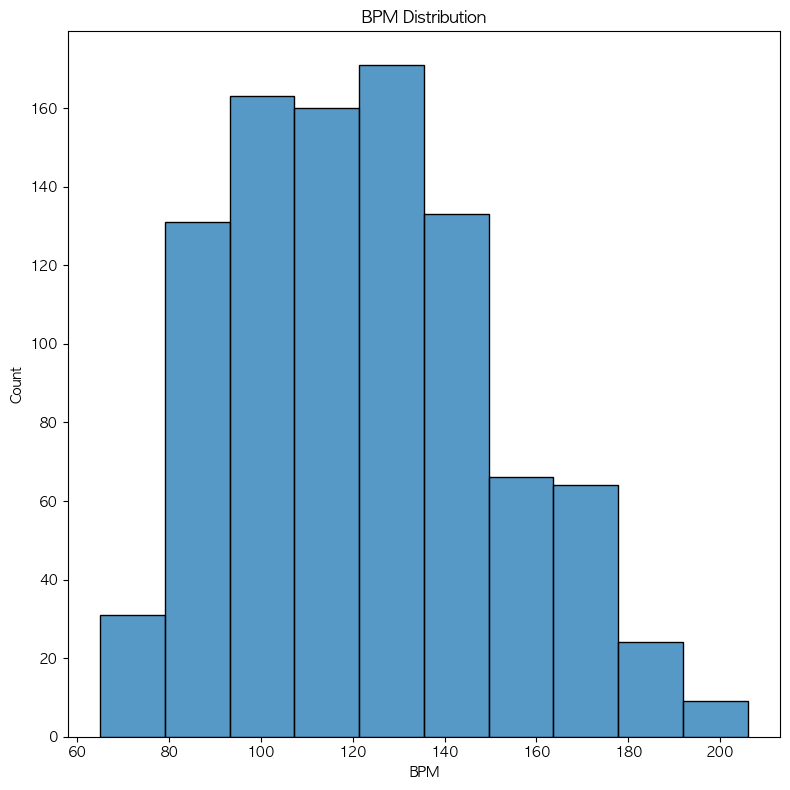

In [63]:
plt.figure(figsize=(8,8))
sns.histplot(data=df, x='bpm', bins=10)
plt.title("BPM Distribution")
plt.xlabel("BPM")
plt.tight_layout()
plt.show()

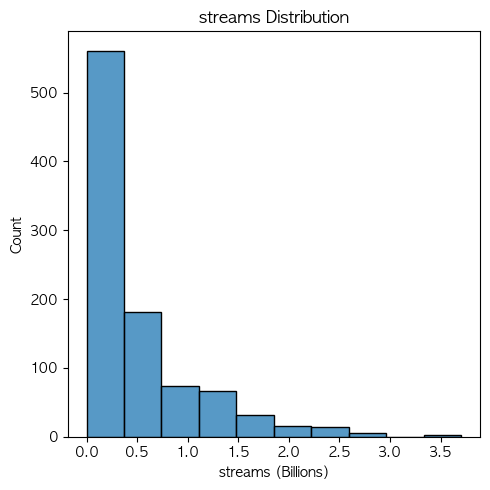

In [64]:
plt.figure(figsize=(5,5))
sns.histplot(data=df, x='streams', bins=10)
plt.title("streams Distribution")
plt.xlabel("streams (Billions)")
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e9:.1f}'))
plt.tight_layout()
plt.show()

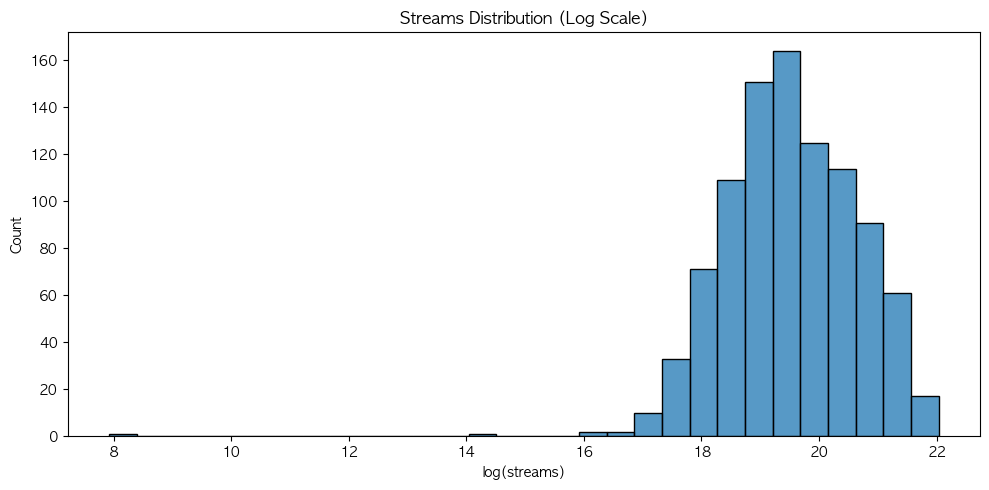

In [65]:
import numpy as np

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df['streams']), bins=30)
plt.title("Streams Distribution (Log Scale)")
plt.xlabel("log(streams)")
plt.tight_layout()
plt.show()

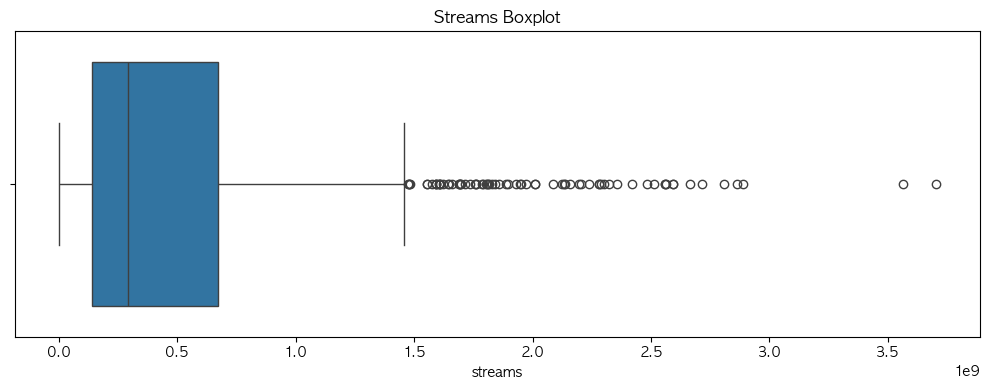

In [66]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['streams'])
plt.title("Streams Boxplot")
plt.tight_layout()
plt.show()

### 4단계 결과
- BPM = 정규분포 (종 모양, 중앙에 집중)\
    100~130 사이에 가장 집중되어 있고, 양 극단(60대, 200대)으로 갈수록 급격히 줄어든다.
- Streams = 지수 분포 / 롱테일 (소수의 곡이 대부분의 스트리밍 차지)\
    대부분의 곡들은 100만 이하의 재생수를 갖고 있고, 높은 재생수를 갖는 곡 수는 점점 줄어든다.
- log 변환을 통한 Streams 분포 확인
- boxplot 오른쪽 점들 = 이상치(outlier) — IQR 범위 벗어난 초인기곡들

** *np.log1p(x) - ML 모델에 데이터 넣을 때 중요한 전처리 기법*
- log는 값이 크게 퍼져있는 롱테일 분포를 압축시켜 정규분포에 가깝게 만든다.
- 여기서 np.log(x)가 아닌 np.log1p(x)를 쓰는 이유는??\
    x에 0이 들어오면 log(0)는 오류를 뱉지만, np.log1p(x)는 log(1 + x)으로 처리하기 때문에 안전하게 변환이 가능하다.



## 결론 — 2023년 인기곡의 공통점

**1. 템포 (BPM)**
인기곡의 BPM은 100~130 사이에 집중된 정규분포를 보임.
대부분의 인기곡은 중간 템포 대역에 위치.

**2. 스트리밍 분포**
소수의 곡(The Weeknd, Taylor Swift 등)이 압도적인 스트리밍을 차지.
전형적인 롱테일 분포 — 상위 1%가 시장을 지배.

**3. 오디오 피처 관계**
- energy ↔ acousticness = -0.58 (강한 음의 상관)
  → 에너지 넘치는 곡일수록 어쿠스틱하지 않음
- danceability ↔ valence = 0.41 (중간 양의 상관)
  → 신나는 곡일수록 긍정적인 감정도가 높음

## 한계점
- 오디오 피처와 스트리밍 수의 직접적인 인과관계는 불명확
- 마케팅, 아티스트 인지도 등 외부 요인 미반영
- 2023년 데이터만으로 장기 트렌드 판단 불가

# Streams 예측 선형회귀 모델
## 1단계 피처랑 타깃 설정

In [76]:
import numpy as np

# 타깃 — log 변환
y = np.log1p(df['streams'])

# 피처
features = ['bpm', 'danceability_%', 'energy_%',
            'valence_%', 'acousticness_%',
            'speechiness_%', 'liveness_%']

X = df[features]

print(X.shape, y.shape)

(952, 7) (952,)


# 2단계 — train/test split
모델을 학습시키고 평가하려면 데이터를 나눠야 한다.\
*왜?* 과적합(Overfitting)이 일어날 수 있기 때문
- 모델이 학습 데이터를 너무 완벽하게 외워버림
- 새로운 데이터가 들어오면 예측을 못함

train set → 모델 학습용 (80%)\
test set → 모델 평가용 (20%) — 학습에 절대 안 씀

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(761, 7) (191, 7)


##  3단계 — 모델 학습(선형회귀 모델 with sklearn)

In [72]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## 4단계 - 예측 & 평가

In [73]:
from sklearn.metrics import mean_squared_error, r2_score

# 예측
y_pred = model.predict(X_test)

# 평가
print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.007553083712389275
MSE: 1.019771235899663


## 결론
오디오 피처만으로는 스트리밍 수를 예측할 수 없다.\
인기는 음악적 특성보다 다음과 같은 외부 요인에 의해 결정된다고 볼 수 있다.
- 아티스트 인지도
- 마케팅 / 플레이리스트 수록
- SNS 바이럴
- 발매 시점

# ML 성능 개선(v2)

In [ ]:
# 다른 피처를 추가해서 성능 개선 도전!!
print(df.columns.tolist()) # 추가 가능한 컬럼 확인

# released_year → 오래된 곡이라서 스트리밍이 많은 건지?
# released_month → 계절/시즌이 영향을 주는지?
# in_spotify_playlists → 플레이리스트 수록 수가 스트리밍과 비례하는지?
# mode, key → 음악적 특성이 영향을 주는지?

['track_name', 'artist(s)_name', 'artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']


In [ ]:
# 선형회귀는 숫자만 받기 때문에 어떻게 바꿀지 확인이 필요
print(df['mode'].unique())
print(df['key'].unique())

# key는 숫자로 변환했을 때 의미 X
# Major = 1, Minor = 0 

['Major' 'Minor']
['B' 'C#' 'F' 'A' 'D' 'F#' nan 'G#' 'G' 'E' 'A#' 'D#']


In [84]:
df['mode_encoded'] = df['mode'].map({'Major': 1, 'Minor': 0})

In [ ]:
# 다른 피처를 추가해서  R² 개선 시도
# - released_year → 오래된 곡이라서 스트리밍이 많은 건지?
# - released_month → 계절/시즌이 영향을 주는지?
# - in_spotify_playlists → 플레이리스트 수록 수가 스트리밍과 비례하는지?
# - mode_encoded → 음악적 특성이 영향을 주는지?

features_v2 = [
    # 오디오 피처
    'bpm', 'danceability_%', 'energy_%', 'valence_%',
    'acousticness_%', 'speechiness_%', 'liveness_%',
    # 새로 추가
    'released_year', 'released_month',
    'in_spotify_playlists', 'in_spotify_charts',
    'mode_encoded'
]

X2 = df[features_v2]
y2 = np.log1p(df['streams'])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)
print("R²:", r2_score(y2_test, y2_pred))
print("MSE:", mean_squared_error(y2_test, y2_pred))

R²: 0.40727816195556865
MSE: 0.6090408176069367


In [ ]:
# 계수 값들이 다 0.001~0.025 수준으로 엄청 작다.
# 스케일이 반영되지 않았기 때문에 계수가 작다고 영향력이 없다고 말할 수 없다
# Ex)
# released_month 계수 = 0.017 — 월이 1 바뀔 때 log(streams)가 0.017 변한다는 뜻
# in_spotify_playlists는 수백~수만 단위 — 계수가 작아 보여도 실제 값이 크면 영향도 커진다.

coef_df = pd.DataFrame({
    'feature': features_v2,
    'coefficient': model2.coef_
}).sort_values('coefficient', ascending=False)

pd.set_option('display.float_format', '{:.6f}'.format)
print(coef_df)

                 feature  coefficient
8         released_month     0.017185
10     in_spotify_charts     0.004154
1         danceability_%     0.001996
0                    bpm     0.000887
3              valence_%     0.000434
9   in_spotify_playlists     0.000090
4         acousticness_%    -0.000447
6             liveness_%    -0.002298
7          released_year    -0.002459
2               energy_%    -0.003721
5          speechiness_%    -0.004443
11          mode_encoded    -0.025568


In [ ]:
# 진짜 중요도를 보려면?
# 각 피처의 실제 기여도 = 계수 × 표준편차
importance = pd.DataFrame({
    'feature': features_v2,
    'coefficient': model2.coef_,
    'std': X2.std().values,
    'impact': abs(model2.coef_ * X2.std().values)
}).sort_values('impact', ascending=False)

print(importance[['feature', 'impact']].to_string())

                 feature   impact
9   in_spotify_playlists 0.712327
10     in_spotify_charts 0.081345
2               energy_% 0.061615
8         released_month 0.061256
5          speechiness_% 0.044058
6             liveness_% 0.031528
1         danceability_% 0.029201
7          released_year 0.027075
0                    bpm 0.024895
11          mode_encoded 0.012639
4         acousticness_% 0.011614
3              valence_% 0.010184


## 결론
in_spotify_playlists = 0.712로 R²가 0.0007 → 0.407로 오르는데 거의 기여했다고 볼 수 있다.
즉, 플레이리스트에 많이 수록될수록 스트리밍이 높아진다 — 음악적 특성보다 플랫폼 노출이 인기를 결정한다